In [24]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

In [25]:
load_dotenv()

True

In [26]:
llm = init_chat_model(model="gemini-3.5-flash-lite", model_provider="google_genai")

In [27]:
class BLOGstate(TypedDict):
    title : str
    outline : str
    blog : str
    evaluation : int

In [28]:
def outline_creator(state : BLOGstate):
    prompt = f"Create an blog outline for this topic: {state['title']}. Only give the outline in response."
    state['outline'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

def blog_writer(state : BLOGstate):
    prompt = f"Write an blog for this topic: {state['title']} using this {state["outline"]}. Only give the blog in response."
    state['blog'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

def blog_evaluation(state : BLOGstate):
    prompt = f"Evaluate the following blog: \n{state['blog']}. Evaluate this and in response only return an interger marking for the blog which will be within the range of 0-100"
    state['evaluation'] = llm.invoke([HumanMessage(content=prompt)]).content
    return state

In [29]:
graph = StateGraph(BLOGstate)

graph.add_node('outline_creator', outline_creator)
graph.add_node('blog_writer', blog_writer)
graph.add_node('blog_evaluation', blog_evaluation)

graph.add_edge(START, 'outline_creator')
graph.add_edge('outline_creator', 'blog_writer')
graph.add_edge('blog_writer', 'blog_evaluation')
graph.add_edge('blog_evaluation', END)

workflow = graph.compile()

In [30]:
initial_state = {'title': "Write an blog about 'The evolution of AI'"}
final_state = workflow.invoke(initial_state)
print(final_state)

{'title': "Write an blog about 'The evolution of AI'", 'outline': [{'type': 'text', 'text': 'I. Introduction\n   A. Hook: The omnipresence of AI in modern life\n   B. Definition: What is Artificial Intelligence?\n   C. Thesis Statement: AI is not a modern overnight success; it is the result of decades of visionary science, winter periods of skepticism, and exponential computing breakthroughs.\n\nII. Phase 1: The Genesis & Theoretical Foundations (1950s–1960s)\n   A. Alan Turing and the Turing Test (1950)\n   B. The Dartmouth Workshop (1956)—where the term "AI" was born\n   C. Early optimism: Rule-based systems and symbolic AI\n\nIII. Phase 2: The Reality Check – The AI Winters (1970s–1980s)\n   A. Limitations of early computers and processing power\n   B. Funding cuts and public disillusionment\n   C. The rise and fall of "Expert Systems"\n\nIV. Phase 3: The Resurgence – Data and Machine Learning (1990s–2000s)\n   A. Shift from rigid rules to learning from data (Machine Learning)\n   B

In [31]:
print(final_state["title"])

Write an blog about 'The evolution of AI'


In [32]:
print(final_state["outline"][0]['text'])

I. Introduction
   A. Hook: The omnipresence of AI in modern life
   B. Definition: What is Artificial Intelligence?
   C. Thesis Statement: AI is not a modern overnight success; it is the result of decades of visionary science, winter periods of skepticism, and exponential computing breakthroughs.

II. Phase 1: The Genesis & Theoretical Foundations (1950s–1960s)
   A. Alan Turing and the Turing Test (1950)
   B. The Dartmouth Workshop (1956)—where the term "AI" was born
   C. Early optimism: Rule-based systems and symbolic AI

III. Phase 2: The Reality Check – The AI Winters (1970s–1980s)
   A. Limitations of early computers and processing power
   B. Funding cuts and public disillusionment
   C. The rise and fall of "Expert Systems"

IV. Phase 3: The Resurgence – Data and Machine Learning (1990s–2000s)
   A. Shift from rigid rules to learning from data (Machine Learning)
   B. Iconic milestones: IBM’s Deep Blue defeats Garry Kasparov (1997)
   C. The explosion of the internet and the

In [33]:
print(final_state["blog"][0]['text'])

# From Punch Cards to Prompt Engineering: The Fascinating Evolution of AI

Look around you. Whether you’re asking your phone for the weather forecast, relying on an algorithm to curate your morning playlist, or using a smart navigation app to dodge morning traffic, Artificial Intelligence is woven into the very fabric of our daily lives. 

Yet, for all its modern ubiquity, AI can feel like a sudden magic trick—a digital revolution that burst onto the scene overnight. But the truth is far more compelling. AI is not a modern overnight success; it is the result of decades of visionary science, winter periods of skepticism, and exponential computing breakthroughs.

Let’s take a journey through time to explore how a sci-fi dream became our everyday reality.

---

## Phase 1: The Genesis & Theoretical Foundations (1950s–1960s)

The story of AI begins in the wake of World War II, fueled by a profound philosophical question: *Can machines think?*

In 1950, brilliant mathematician Alan Turing p

In [34]:
print(final_state["evaluation"][0]['text'])

95


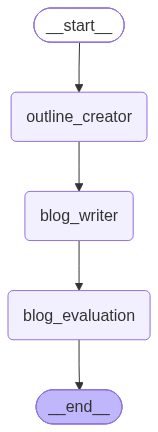

In [35]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))